# Sentiment Analysis using Machine Learning

In [1]:
#import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
#Download NLTK

import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [5]:
#Upload Dataset

from google.colab import files

uploaded = files.upload()

Saving nlp_dataset.csv to nlp_dataset.csv


In [6]:
#Load Dataset

df = pd.read_csv("nlp_dataset.csv")

df.head()

,Comment,Emotion
0,i seriously hate one subject to death but now ...,fear
1,im so full of life i feel appalled,anger
2,i sit here to write i start to dig out my feel...,fear
3,ive been really angry with r and i feel like a...,joy
4,i feel suspicious if there is no one outside l...,fear


In [9]:
#Dataset Information

df.shape


(5937, 2)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5937 entries, 0 to 5936
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Comment  5937 non-null   object
 1   Emotion  5937 non-null   object
dtypes: object(2)
memory usage: 92.9+ KB


In [11]:
df.describe(include="object")

,Comment,Emotion
count,5937,5937
unique,5934,3
top,i feel pretty tortured because i work a job an...,anger
freq,2,2000


In [12]:
df.isnull().sum()

,0
Comment,0
Emotion,0


In [13]:
df["Emotion"].value_counts()

,count
Emotion,
anger,2000
joy,2000
fear,1937


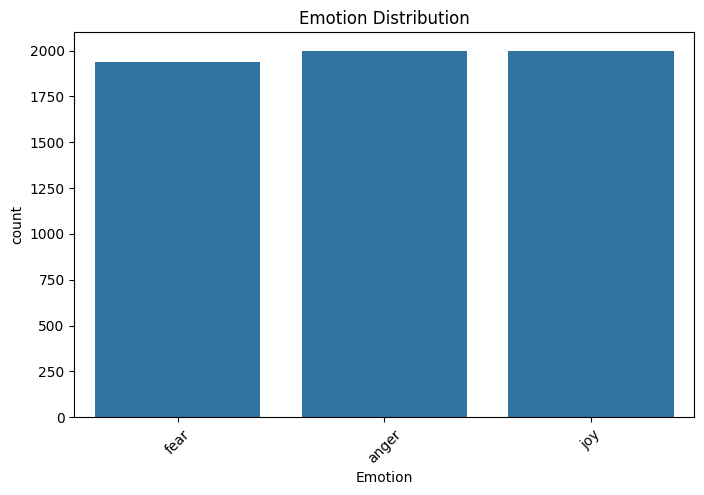

In [14]:
#Emotion Distribution

plt.figure(figsize=(8,5))
sns.countplot(x="Emotion", data=df)
plt.title("Emotion Distribution")
plt.xticks(rotation=45)
plt.show()




The bar chart illustrates the distribution of the three emotion classes in the dataset: fear, anger, and joy. The dataset is nearly balanced, with anger and joy containing 2,000 samples each and fear containing approximately 1,937 samples. A balanced dataset helps machine learning models learn each class effectively and reduces prediction bias.

1. Loading and Preprocessing

In [15]:
# Text Preprocessing

stop_words = set(stopwords.words("english"))

def clean_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+", "", text)

    # Remove punctuation and numbers
    text = re.sub(r"[^a-zA-Z ]", "", text)

    # Tokenization
    words = word_tokenize(text)

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Join words back into a sentence
    return " ".join(words)

# Apply preprocessing to the Comment column
df["Clean_Text"] = df["Comment"].apply(clean_text)

# Display first five rows
df[["Comment", "Clean_Text"]].head()

,Comment,Clean_Text
0,i seriously hate one subject to death but now ...,seriously hate one subject death feel reluctan...
1,im so full of life i feel appalled,im full life feel appalled
2,i sit here to write i start to dig out my feel...,sit write start dig feelings think afraid acce...
3,ive been really angry with r and i feel like a...,ive really angry r feel like idiot trusting fi...
4,i feel suspicious if there is no one outside l...,feel suspicious one outside like rapture happe...


Text Preprocessing:

The text data was preprocessed before feature extraction to improve the quality of the input data. The following preprocessing techniques were applied:



*   Converted all text to lowercase to maintain consistency.
*  Removed URLs, punctuation, numbers, and special characters.
*   Tokenized the text into individual words.
*   Removed English stopwords such as the, is, and, and to.
*   Stored the processed text in a new column named Clean_Text.

Impact on Model Performance:

These preprocessing techniques reduce noise, eliminate irrelevant words, and retain only meaningful information. As a result, the machine learning models can learn more effectively from the text, improving classification accuracy and overall performance.







2. Feature extraction

In [16]:
# Feature Extraction using TF-IDF

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["Clean_Text"])

y = df["Emotion"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (5937, 5000)
Target Shape: (5937,)


Feature Extraction using TF-IDF

The TF-IDF Vectorizer transformed the cleaned text into a numerical feature matrix with 5,937 samples and 5,000 features. Each feature represents the importance of a word in the dataset. The target variable contains 5,937 emotion labels, corresponding to each text sample. These numerical features are then used to train the machine learning models.

3. Model Development

In [17]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (4749, 5000)
Testing Data Shape: (1188, 5000)


In [19]:
# Naive Bayes Model

nb = MultinomialNB()

nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

In [20]:
# Naive Bayes Evaluation

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))

print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.9082491582491582
              precision    recall  f1-score   support

       anger       0.87      0.95      0.91       392
        fear       0.91      0.92      0.91       416
         joy       0.94      0.86      0.90       380

    accuracy                           0.91      1188
   macro avg       0.91      0.91      0.91      1188
weighted avg       0.91      0.91      0.91      1188



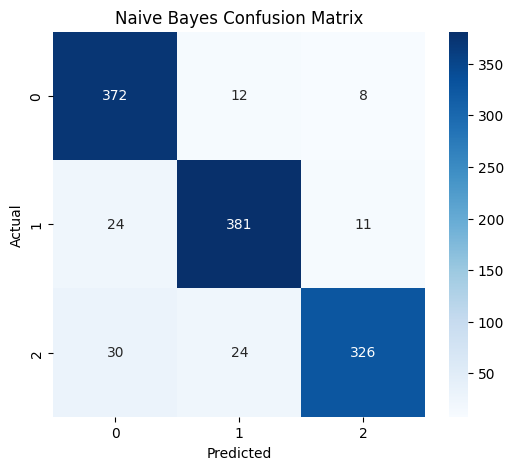

In [23]:
#Naive Bayes Confusion Matrix

cm = confusion_matrix(y_test, nb_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



The Naive Bayes model achieved an accuracy of 90.82% with a macro F1-score of 0.91. The confusion matrix shows that the majority of emotion classes were correctly classified, although a few samples were misclassified. Overall, the model performs well for emotion classification.

In [21]:
# Support Vector Machine Model

svm = LinearSVC()

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

In [22]:
# SVM Evaluation

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.952020202020202
              precision    recall  f1-score   support

       anger       0.94      0.96      0.95       392
        fear       0.97      0.93      0.95       416
         joy       0.95      0.97      0.96       380

    accuracy                           0.95      1188
   macro avg       0.95      0.95      0.95      1188
weighted avg       0.95      0.95      0.95      1188



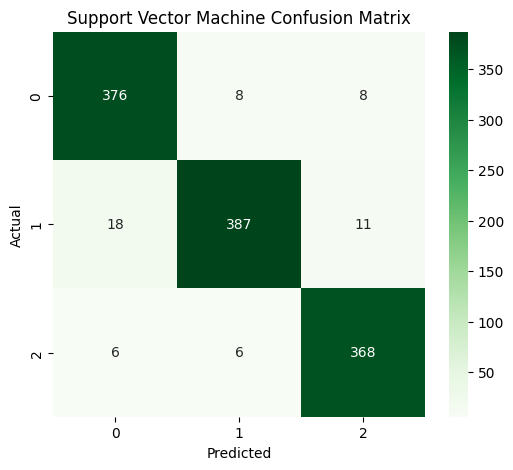

In [24]:
#SVM Confusion Matrix

cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Support Vector Machine Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The Support Vector Machine achieved an accuracy of 95.20% with a macro F1-score of 0.95. The confusion matrix indicates that most emotion samples were correctly classified, with fewer misclassifications than the Naive Bayes model. This demonstrates that SVM provides superior performance for emotion classification on this dataset.

Conclusion

In this assignment, an emotion classification model was developed using machine learning techniques. The text data was preprocessed by converting it to lowercase, removing punctuation and stopwords, and tokenizing the text. The cleaned text was transformed into numerical features using the TF-IDF Vectorizer. Two machine learning models, Naive Bayes and Support Vector Machine (SVM), were trained and evaluated using Accuracy, Precision, Recall, and F1-score. The results showed that Support Vector Machine (SVM) achieved the best performance with an accuracy of 95.20% and a macro F1-score of 0.95, outperforming the Naive Bayes model. Therefore, SVM is the most suitable model for emotion classification on this dataset due to its high accuracy and ability to effectively classify text into different emotion categories.